In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

%matplotlib inline

# Introduction

In [2]:
iris_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
df_iris = pd.read_csv(iris_url, names=['sepal length','sepal width','petal length','petal width','target'])

df_iris.head(5)

,sepal length,sepal width,petal length,petal width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


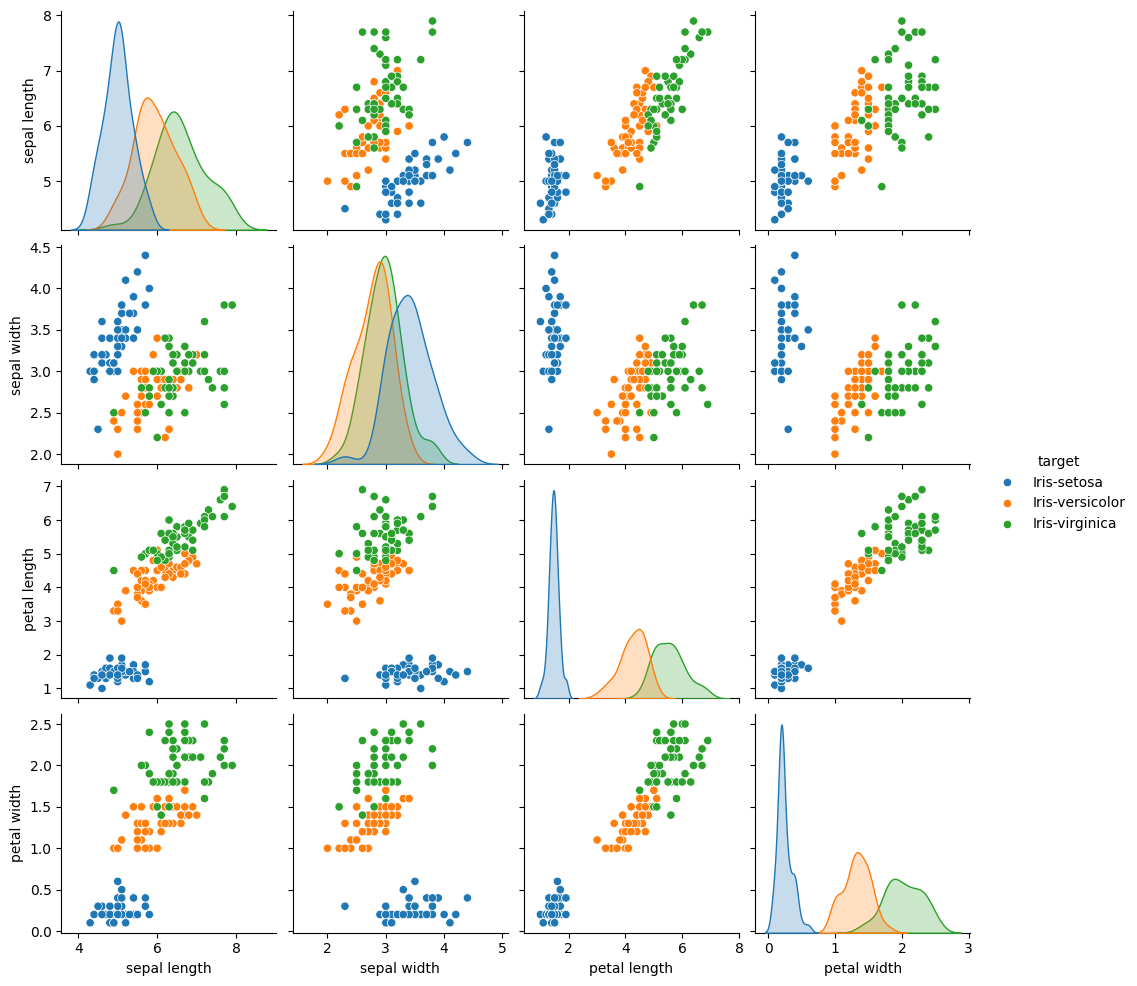

In [3]:
sns.pairplot(df_iris, hue='target')

In [4]:
# Petal length and petal width exhibit a strong linear correlation, as a straight line can closely approximate the distribution of the data points.
# When one of these features increases, the other tends to increase as well, and vice versa.

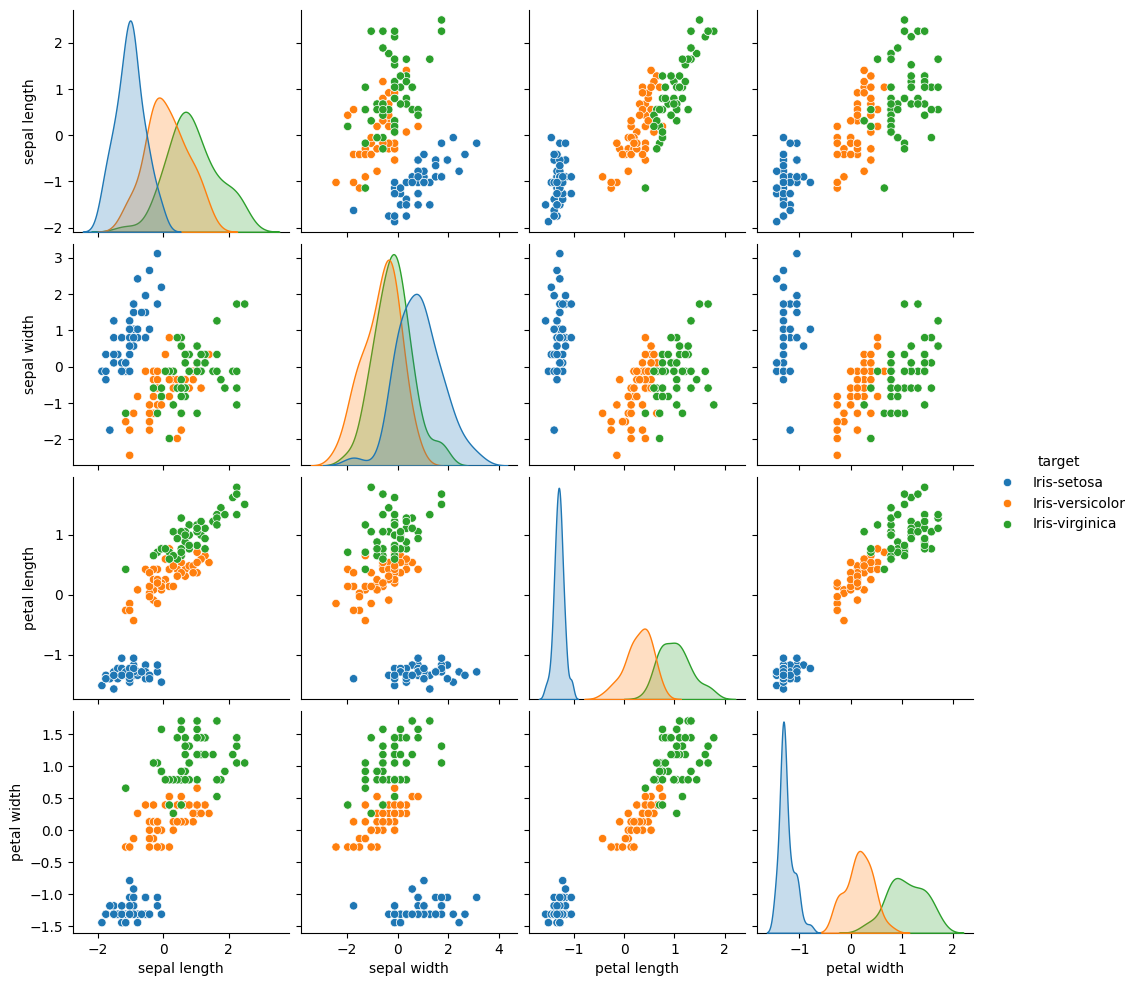

In [5]:
features_iris = ['sepal length', 'sepal width', 'petal length', 'petal width']
x_iris = df_iris.loc[:, features_iris].values

y_iris = df_iris.loc[:,['target']].values

x_iris = StandardScaler().fit_transform(x_iris)

df_iris_standarize = pd.DataFrame(data = x_iris, columns = features_iris)
df_iris_standarize['target'] = df_iris['target']

sns.pairplot(df_iris_standarize, hue='target')

In [6]:
pca_iris = PCA(n_components=2)

principal_components_iris = pca_iris.fit_transform(x_iris)
principal_df_iris = pd.DataFrame(data = principal_components_iris, columns = ['principal component 1', 'principal component 2'])

final_df_iris = pd.concat([principal_df_iris, df_iris[['target']]], axis = 1)
final_df_iris.head(15)

,principal component 1,principal component 2,target
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa
5,-2.070537,1.518549,Iris-setosa
6,-2.445711,0.074563,Iris-setosa
7,-2.233842,0.247614,Iris-setosa
8,-2.341958,-1.095146,Iris-setosa
9,-2.188676,-0.448629,Iris-setosa


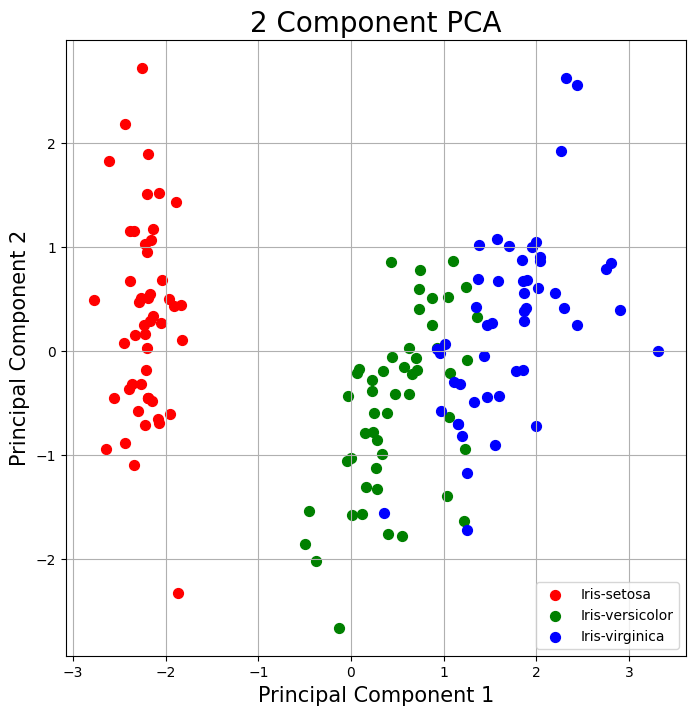

In [7]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 Component PCA', fontsize = 20)

iris_targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
for target, color in zip(iris_targets, colors):
    indices_to_keep = final_df_iris['target'] == target

    ax.scatter(
        final_df_iris.loc[indices_to_keep, 'principal component 1'],
        final_df_iris.loc[indices_to_keep, 'principal component 2'],
        c = color,
        s = 50
    )
#

ax.legend(iris_targets)
ax.grid()

In [8]:
pca_iris.explained_variance_ratio_

array([0.72770452, 0.23030523])

# Makemoons

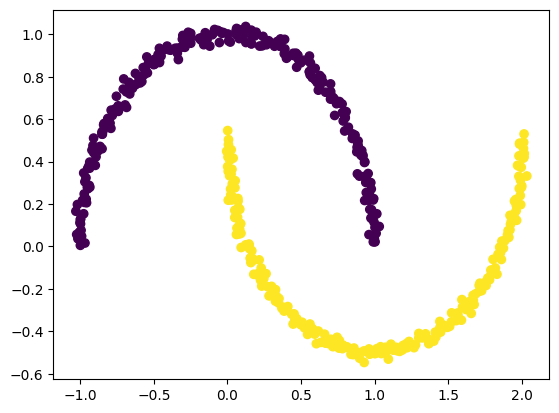

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples = 500, noise = 0.02, random_state = 417)

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show()

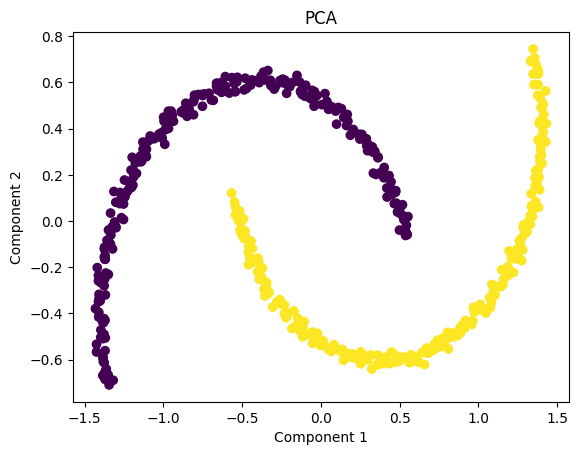

In [10]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

plt.title("PCA")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = y)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

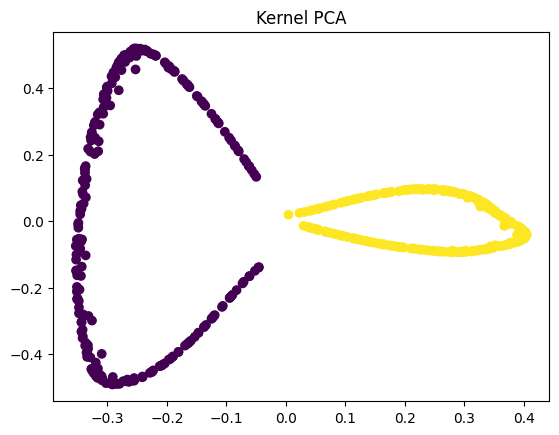

In [11]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel ='rbf', gamma = 15)
X_kpca = kpca.fit_transform(X)

plt.title("Kernel PCA")
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c = y)
plt.show()